# Lab 4: Variational inference in the *Latent Dirichlet Allocation* model

## Advanced Statistical Estimation, Centrale Lille

This last lab is about the *Latent Dirichlet Allocation* model ([Blei et al. (2003)](https://www.jmlr.org/papers/volume3/blei03a/blei03a.pdf)), a well-known probabilistic model for text data. The posterior of this model is intractable, and we use the variational approach to approximate it.

Using the notations from the .pdf file describing the model, the intractable posterior is:
$$p(\boldsymbol{\beta}, \boldsymbol{\theta} | \mathcal{D}),$$
which we approximate as follows:
$$\simeq \left[ \prod_{k=1}^K q(\boldsymbol{\beta_k}) \right] \left[ \prod_{d=1}^D q(\boldsymbol{\theta_d}) \right] , $$
with:
* $q(\boldsymbol{\beta_k})$ a Dirichlet distribution (of size V) with variational parameters $[\lambda_{k1}, ...,\lambda_{kV}]$;
* $q(\boldsymbol{\theta_d})$ a Dirichlet distribution (of size K) with variational parameters $[\gamma_{d1}, ...,\gamma_{dK}]$.

**Report by Ugo Roccamatisi.**


In [1]:
# Import usual libraries
import numpy as np
from matplotlib import pyplot as plt

# Specific for this lab
from sklearn.decomposition import LatentDirichletAllocation

**Q0.** What would be the main difficulty for an MCMC algorithm in this setting?

**Answer.** A Gibbs sampler is possible thanks to conjugacy, but it would have to update the latent assignments of the many words in every document, as well as the topic-word and document-topic distributions; the cost and the autocorrelation of the chains make the computation heavy at this scale. The variational method provides an optimized approximation that is easier to apply to the whole corpus.

### Part 1 - Data preparation

We use the `20newsgroups` dataset (see for example [here](https://scikit-learn.org/stable/datasets/real_world.html#newsgroups-dataset)), which contains messages posted in different categories of an online forum in the 1990s.

In [2]:
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer
# Bundled cache to avoid a download when re-running.
newsgroups=fetch_20newsgroups(data_home='./sklearn_data',subset='train').data
print('Documents loaded:',len(newsgroups))

Documents loaded: 11314


**Q1.** In LDA, how is a document represented?

**Answer.** A document is a bag of words: a vector of length V giving the number of occurrences of each vocabulary word. Word order is lost in this model.

**Q2.** Build the data matrix with `CountVectorizer` using the arguments:
* `max_df` = 0.95;
* `max_features` = 1000;
* `stop_words` = "english".

Explain what these 3 arguments mean.

In [3]:
vectorizer=CountVectorizer(max_df=.95,max_features=1000,stop_words='english')
X=vectorizer.fit_transform(newsgroups)
vocab=vectorizer.get_feature_names_out()
print('Document × word matrix:',X.shape,'; first words:',vocab[:15])

Document × word matrix: (11314, 1000) ; first words: ['00' '000' '01' '02' '03' '04' '0d' '0t' '10' '100' '11' '12' '13' '14'
 '145']


**Answer.** `max_df=0.95` ignores terms that appear in more than 95% of the documents; `max_features=1000` keeps at most 1000 words, ranked by frequency; `stop_words="english"` removes common, uninformative English words.

**Q3.** Recall what the dimensions of the data matrix correspond to.

Compute its percentage of non-zero entries. Is it surprising?

In [4]:
density=100*X.nnz/(X.shape[0]*X.shape[1])
print('Observations / words:',X.shape,'; non-zero entries:',X.nnz)
print(f'Density: {density:.3f}% ; sparse matrix: {100-density:.3f}% zeros')

Observations / words: (11314, 1000) ; non-zero entries: 499682
Density: 4.416% ; sparse matrix: 95.584% zeros


**Answer.** Each row is a document and each column a vocabulary word; each entry is a number of occurrences. The matrix is very sparse because a document uses only a small fraction of the 1000 selected words.

### Part 2 - Latent Dirichlet Allocation (LDA)

**Q4.** Train the LDA model with the following arguments:
* `n_components` = 8;
* `learning_method` = "online";
* `max_iter` = 50;
* `doc_topic_prior` = 0.1;
* `topic_word_prior` = 0.1;
* `learning_offset` = 100.

Again, explain what each of these arguments means.

In [5]:
lda=LatentDirichletAllocation(n_components=8,learning_method='online',max_iter=50,
    doc_topic_prior=.1,topic_word_prior=.1,learning_offset=100,
    random_state=0,n_jobs=1)
lda.fit(X)
print('Number of iterations:',lda.n_iter_,'; topics × words shape:',lda.components_.shape)
print('Training perplexity (indicative, not predictive):',lda.perplexity(X))

Number of iterations: 50 ; topics × words shape: (8, 1000)


Training perplexity (indicative, not predictive): 344.59266991208557


**Answer.** `n_components=8` sets eight topics; `learning_method="online"` performs variational updates on mini-batches; `max_iter=50` limits the number of passes over the corpus; `doc_topic_prior=0.1` and `topic_word_prior=0.1` set the Dirichlet concentrations α and η (low values favor less uniform distributions); `learning_offset=100` down-weights the first online updates. The training perplexity is descriptive and is not enough to choose K.

**Q5.** What does the `.components_` attribute contain?

How can the MMSE of $\boldsymbol{\beta}$ be obtained from this attribute? Implement it.

In [6]:
# components_[k,v]: variational Dirichlet parameter of word v for topic k.
# Its posterior expectation is the parameter divided by its row sum.
beta_mmse=lda.components_/lda.components_.sum(axis=1,keepdims=True)
print('Shape of the topic-word means:',beta_mmse.shape)
print('Row sums per topic:',np.round(beta_mmse.sum(axis=1),8))

Shape of the topic-word means: (8, 1000)
Row sums per topic: [1. 1. 1. 1. 1. 1. 1. 1.]


**Answer.** `.components_` holds the variational parameters λ of each topic's Dirichlet distribution over words, not normalized probabilities. The expectation (MMSE estimator of β under quadratic loss) is λ_kv / Σ_v λ_kv; each row of `beta_mmse` sums to 1.

**Q6.** From $\hat{\boldsymbol{\beta}}_{MMSE}$, display the 10 most frequent words per topic. Can you interpret the topics?

To add words to the stop-word list and improve interpretability, use the code block below.

In [7]:
for k,row in enumerate(beta_mmse):
    words=vocab[np.argsort(row)[-10:][::-1]]
    print(f'Topic {k+1}:',', '.join(words))

Topic 1: space, key, gov, nasa, use, access, chip, netcom, encryption, data
Topic 2: drive, card, edu, use, scsi, ibm, problem, mac, apple, bit
Topic 3: windows, file, edu, 10, 00, program, mail, use, available, 15
Topic 4: edu, university, writes, article, posting, nntp, host, cs, ca, like
Topic 5: god, people, edu, don, think, does, say, just, know, believe
Topic 6: com, writes, article, posting, host, nntp, distribution, hp, ca, reply
Topic 7: ax, max, g9v, b8f, a86, 145, pl, 0d, 1d9, 34u
Topic 8: people, don, said, just, car, like, think, time, know, government


In [8]:
# Optional extension: customize, then refit the vectorizer and LDA if needed.
from sklearn.feature_extraction import text
my_additional_stop_words=[]
my_stop_words=text.ENGLISH_STOP_WORDS.union(my_additional_stop_words)
print('Additional stop words in the current version:',my_additional_stop_words)

Additional stop words in the current version: []


**Answer.** Topics 1 to 3 relate to space and cryptography, computer hardware, and Windows and software. Topic 5 is about religion; topic 8 mixes general discussion, cars and government. Topics 4 and 6 mostly capture message headers (`edu`, `writes`, `article`, `nntp`, `host`). Topic 7 gathers alphanumeric strings (`ax`, `g9v`, etc.) rather than a readable theme, which points to noise or encoded content. Removing headers, signatures and quotes, then tuning the stop words, would probably improve interpretability; any new preprocessing requires retraining the model.


**Q7.** What does `lda.transform(X)` contain?

Check whether documents are usually associated with one topic or several.

Documents × topics shape: (11314, 8)
Sums of the proportions (5 documents): [1. 1. 1. 1. 1.]
Share with a dominant topic > 0.5: 0.6552059395439279
Mean number of topics per document with weight > 0.2: 1.8468269400742443


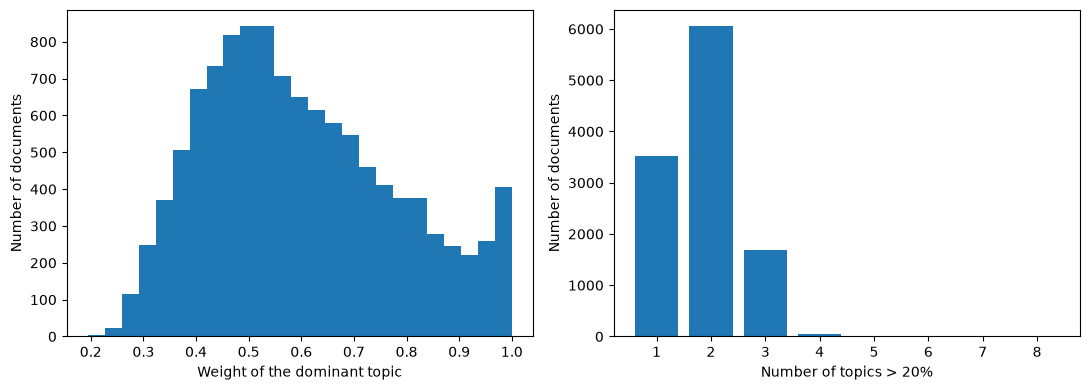

In [9]:
doc_topic=lda.transform(X)
max_probability=doc_topic.max(axis=1)
number_above_20=(doc_topic>.20).sum(axis=1)
print('Documents × topics shape:',doc_topic.shape)
print('Sums of the proportions (5 documents):',np.round(doc_topic[:5].sum(axis=1),6))
print('Share with a dominant topic > 0.5:',np.mean(max_probability>.5))
print('Mean number of topics per document with weight > 0.2:',number_above_20.mean())
fig,axes=plt.subplots(1,2,figsize=(11,4))
axes[0].hist(max_probability,bins=25);axes[0].set(xlabel='Weight of the dominant topic',ylabel='Number of documents')
axes[1].bar(np.arange(1,9),np.bincount(number_above_20,minlength=9)[1:]);axes[1].set(xlabel='Number of topics > 20%',ylabel='Number of documents')
fig.tight_layout();plt.show()

**Answer.** `lda.transform(X)` returns, for each document, an estimated distribution over the eight topics, summing to 1. Here about **65.5%** of the documents have a dominant topic with weight above 0.5, and there are on average **1.85 topics** with weight above 0.2 per document. Some documents therefore mix several themes.


### Part 3 - Going further

Answer the questions without implementing the solutions discussed.

**Q8.** What is the influence of the parameters $\alpha$ and $\eta$?

**Answer.** A low α associates documents mainly with few topics; a high α mixes them more. A low η concentrates each topic on few words; a high η spreads it over more terms. Their effect also depends on the size of the corpus and of the vocabulary.

**Q9.** Here the number of topics $K$ was fixed in advance. How could the value of $K$ be learned or chosen?

**Answer.** Train several values of K with the same preprocessing and compare the perplexity on held-out documents; also examine the coherence and interpretability of the words and the stability of the topics. Non-parametric models can also learn a variable complexity.

**Q10.** What are the main limitations of the LDA model, and which improvements would you suggest?

**Answer.** The bag of words ignores order and context: polysemy, negation and multi-word expressions are poorly represented. A fixed K and topics independent of metadata also limit the model. N-grams, dynamic or hierarchical models, and contextual representations can take this information into account better.